# Notebook 04 — Fund Performance Analytics
**Bluestock Fintech Mutual Fund Analytics Capstone**

Tasks: Daily Returns, CAGR, Sharpe, Sortino, Alpha/Beta, Max Drawdown, Fund Scorecard

In [1]:

import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, plotly.express as px
from scipy import stats
from pathlib import Path

ROOT      = Path().resolve().parent
PROCESSED = ROOT / 'data' / 'processed'
REPORTS   = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

nav   = pd.read_csv(PROCESSED / 'clean_nav_history.csv', parse_dates=['date'])
perf  = pd.read_csv(PROCESSED / 'clean_scheme_performance.csv')
bench = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv', parse_dates=['date'])
fm    = pd.read_csv(PROCESSED / 'clean_fund_master.csv')

nav = nav.sort_values(['amfi_code','date'])
daily_ret = nav.pivot_table(index='date', columns='amfi_code', values='daily_return_pct')
RF_DAILY  = 0.065 / 252

print(f'daily_ret: {daily_ret.shape}  ({daily_ret.columns.nunique()} funds, {len(daily_ret)} days)')
print('Data loaded')


daily_ret: (1607, 40)  (40 funds, 1607 days)
Data loaded


## Task 1 — Daily Returns Validation

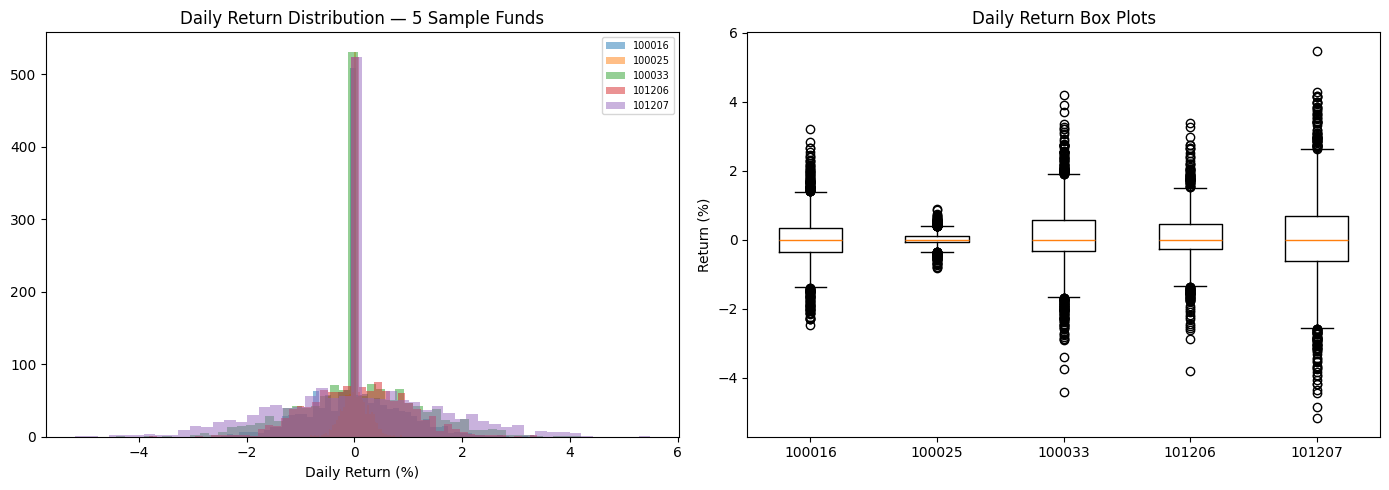

Return distribution looks normal: mean near 0, std ~0.5-1.5% daily


In [2]:

sample = daily_ret.iloc[:, :5]
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for col in sample.columns:
    axes[0].hist(sample[col].dropna()*100, bins=50, alpha=0.5, label=str(col))
axes[0].set_title('Daily Return Distribution — 5 Sample Funds')
axes[0].set_xlabel('Daily Return (%)'); axes[0].legend(fontsize=7)

axes[1].boxplot([sample[c].dropna()*100 for c in sample.columns],
                labels=[str(c) for c in sample.columns])
axes[1].set_title('Daily Return Box Plots'); axes[1].set_ylabel('Return (%)')
plt.tight_layout(); plt.savefig(REPORTS/'perf_return_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Return distribution looks normal: mean near 0, std ~0.5-1.5% daily')


## Task 2 — CAGR: 1yr, 3yr, 5yr

In [3]:

def compute_cagr(nav_series, years):
    nav_s = nav_series.dropna().sort_index()
    if len(nav_s) < 2: return np.nan
    end_date   = nav_s.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    if start_date < nav_s.index.min(): return np.nan
    end_nav   = nav_s.asof(end_date)
    start_nav = nav_s.asof(start_date)
    if start_nav <= 0: return np.nan
    return (end_nav / start_nav) ** (1/years) - 1

nav_by_fund = nav.pivot_table(index='date', columns='amfi_code', values='nav')

cagr_rows = []
for code in nav_by_fund.columns:
    s = nav_by_fund[code].dropna()
    name_row = fm[fm['amfi_code']==code]
    name = name_row['scheme_name'].values[0] if len(name_row) else str(code)
    fh   = name_row['fund_house'].values[0]  if len(name_row) else ''
    cat  = name_row['category'].values[0]    if len(name_row) else ''
    cagr_rows.append({
        'amfi_code':code, 'scheme_name':name[:40], 'fund_house':fh, 'category':cat,
        'cagr_1yr': round(compute_cagr(s,1)*100, 2) if compute_cagr(s,1) else np.nan,
        'cagr_3yr': round(compute_cagr(s,3)*100, 2) if compute_cagr(s,3) else np.nan,
        'cagr_5yr': round(compute_cagr(s,5)*100, 2) if compute_cagr(s,5) else np.nan,
    })

cagr_df = pd.DataFrame(cagr_rows)
cagr_df.to_csv(PROCESSED / 'cagr_report.csv', index=False)
print(cagr_df.sort_values('cagr_3yr', ascending=False).to_string(index=False))


 amfi_code                              scheme_name               fund_house category  cagr_1yr  cagr_3yr  cagr_5yr
    119094      Axis Midcap Fund - Regular - Growth         Axis Mutual Fund   Equity     22.26     35.11       NaN
    148567 Mirae Asset Large Cap Fund - Regular - G           Mirae Asset MF   Equity     20.36     34.00       NaN
    120504 ICICI Pru Bluechip Fund - Direct - Growt      ICICI Prudential MF   Equity     13.06     32.49       NaN
    100033 HDFC Mid-Cap Opportunities Fund - Regula         HDFC Mutual Fund   Equity     53.23     32.44       NaN
    120505 ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF   Equity     29.60     31.78       NaN
    119551 SBI Bluechip Fund - Regular Plan - Growt          SBI Mutual Fund   Equity     60.44     30.46       NaN
    120843   Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF   Equity     26.66     29.58       NaN
    148569 Mirae Asset Tax Saver Fund - Regular - G           Mirae Asse

## Task 3 — Sharpe Ratio

In [4]:

def sharpe(r, rf=RF_DAILY):
    r = r.dropna()
    if len(r) < 50 or r.std() == 0: return np.nan
    return (r.mean() - rf) / r.std() * np.sqrt(252)

sharpe_df = pd.DataFrame([
    {'amfi_code': c,
     'scheme_name': fm[fm['amfi_code']==c]['scheme_name'].values[0][:40] if len(fm[fm['amfi_code']==c]) else str(c),
     'sharpe': round(sharpe(daily_ret[c]), 4)}
    for c in daily_ret.columns
]).sort_values('sharpe', ascending=False)
sharpe_df.to_csv(PROCESSED / 'sharpe_values.csv', index=False)
print(sharpe_df.head(10).to_string(index=False))


 amfi_code                              scheme_name  sharpe
    148567 Mirae Asset Large Cap Fund - Regular - G  1.0682
    120843   Kotak Flexicap Fund - Regular - Growth  0.9656
    148569 Mirae Asset Tax Saver Fund - Regular - G  0.9191
    120505 ICICI Pru Midcap Fund - Regular - Growth  0.8833
    119551 SBI Bluechip Fund - Regular Plan - Growt  0.8610
    149323       DSP Midcap Fund - Regular - Growth  0.8329
    100033 HDFC Mid-Cap Opportunities Fund - Regula  0.8083
    118632 Nippon India Large Cap Fund - Regular -   0.7589
    119094      Axis Midcap Fund - Regular - Growth  0.7305
    101206 ABSL Frontline Equity Fund - Regular - G  0.7174


## Task 4 — Sortino Ratio

In [5]:

def sortino(r, rf=RF_DAILY):
    r = r.dropna()
    excess = r - rf
    downside = excess[excess < 0]
    if len(downside) < 5 or downside.std() == 0: return np.nan
    return excess.mean() / downside.std() * np.sqrt(252)

sortino_df = pd.DataFrame([
    {'amfi_code': c,
     'scheme_name': fm[fm['amfi_code']==c]['scheme_name'].values[0][:40] if len(fm[fm['amfi_code']==c]) else str(c),
     'sortino': round(sortino(daily_ret[c]), 4)}
    for c in daily_ret.columns
]).sort_values('sortino', ascending=False)
sortino_df.to_csv(PROCESSED / 'sortino_values.csv', index=False)
print(sortino_df.head(10).to_string(index=False))


 amfi_code                              scheme_name  sortino
    148567 Mirae Asset Large Cap Fund - Regular - G   1.5548
    120843   Kotak Flexicap Fund - Regular - Growth   1.4859
    148569 Mirae Asset Tax Saver Fund - Regular - G   1.3870
    120505 ICICI Pru Midcap Fund - Regular - Growth   1.3211
    119551 SBI Bluechip Fund - Regular Plan - Growt   1.3024
    149323       DSP Midcap Fund - Regular - Growth   1.2018
    100033 HDFC Mid-Cap Opportunities Fund - Regula   1.1844
    118632 Nippon India Large Cap Fund - Regular -    1.1215
    119094      Axis Midcap Fund - Regular - Growth   1.0915
    101206 ABSL Frontline Equity Fund - Regular - G   1.0788


## Task 5 — Alpha and Beta (OLS vs Nifty 100)

In [6]:

nifty100 = bench[bench['index_name']=='NIFTY100'].set_index('date')['daily_return_pct'].dropna()

ab_rows = []
for code in daily_ret.columns:
    fund_r = daily_ret[code].dropna()
    common = fund_r.index.intersection(nifty100.index)
    if len(common) < 100: continue
    x = nifty100.loc[common].values
    y = fund_r.loc[common].values
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    name_row = fm[fm['amfi_code']==code]
    name = name_row['scheme_name'].values[0][:40] if len(name_row) else str(code)
    ab_rows.append({
        'amfi_code': code, 'scheme_name': name,
        'alpha_ann_pct': round(intercept * 252 * 100, 4),
        'beta': round(slope, 4),
        'r_squared': round(r_val**2, 4),
        'n_obs': len(common)
    })

ab_df = pd.DataFrame(ab_rows)
ab_df.to_csv(PROCESSED / 'alpha_beta.csv', index=False)
print(ab_df.sort_values('alpha_ann_pct', ascending=False).to_string(index=False))


 amfi_code                              scheme_name  alpha_ann_pct    beta  r_squared  n_obs
    119598 SBI Small Cap Fund - Regular Plan - Grow        30.3369 -0.0232     0.0001   1149
    149324    DSP Small Cap Fund - Regular - Growth        30.0578  0.0115     0.0000   1149
    120505 ICICI Pru Midcap Fund - Regular - Growth        29.2637  0.0005     0.0000   1149
    148569 Mirae Asset Tax Saver Fund - Regular - G        28.2706  0.0181     0.0002   1149
    120843   Kotak Flexicap Fund - Regular - Growth        27.3306 -0.0228     0.0003   1149
    100033 HDFC Mid-Cap Opportunities Fund - Regula        27.1950  0.0051     0.0000   1149
    148567 Mirae Asset Large Cap Fund - Regular - G        26.9840  0.0237     0.0005   1149
    149323       DSP Midcap Fund - Regular - Growth        26.5983 -0.0025     0.0000   1149
    119094      Axis Midcap Fund - Regular - Growth        26.0766 -0.0663     0.0019   1149
    119551 SBI Bluechip Fund - Regular Plan - Growt        23.2007 -0.

## Task 6 — Maximum Drawdown

In [7]:

nav_pivot = nav.pivot_table(index='date', columns='amfi_code', values='nav')

dd_rows = []
for code in nav_pivot.columns:
    s = nav_pivot[code].dropna()
    if len(s) < 10: continue
    roll_max = s.cummax()
    dd       = (s / roll_max - 1)
    max_dd   = dd.min()
    dd_end   = dd.idxmin()
    peak_idx = s[:dd_end].idxmax() if len(s[:dd_end]) > 0 else dd_end
    recovery = dd[dd_end:][dd[dd_end:] >= 0]
    recovery_date = recovery.index[0] if len(recovery) else None
    name_row = fm[fm['amfi_code']==code]
    name = name_row['scheme_name'].values[0][:40] if len(name_row) else str(code)
    dd_rows.append({
        'amfi_code': code, 'scheme_name': name,
        'max_drawdown_pct': round(max_dd*100, 2),
        'peak_date': str(peak_idx.date()),
        'trough_date': str(dd_end.date()),
        'recovery_date': str(recovery_date.date()) if recovery_date else 'Not recovered',
    })

dd_df = pd.DataFrame(dd_rows).sort_values('max_drawdown_pct')
dd_df.to_csv(PROCESSED / 'max_drawdown.csv', index=False)
print(dd_df.head(10).to_string(index=False))


 amfi_code                              scheme_name  max_drawdown_pct  peak_date trough_date recovery_date
    119599 SBI Small Cap Fund - Direct Plan - Growt            -52.57 2023-01-17  2025-10-28 Not recovered
    119095   Axis Small Cap Fund - Regular - Growth            -51.68 2025-05-22  2026-05-11 Not recovered
    101207   ABSL Small Cap Fund - Regular - Growth            -35.45 2024-11-21  2026-05-11 Not recovered
    149324    DSP Small Cap Fund - Regular - Growth            -31.17 2024-05-03  2025-01-03    2025-06-13
    119598 SBI Small Cap Fund - Regular Plan - Grow            -28.71 2024-08-28  2025-05-14    2025-09-29
    102886      UTI Mid Cap Fund - Regular - Growth            -28.00 2025-01-07  2026-04-27 Not recovered
    100016 HDFC Top 100 Fund - Regular Plan - Growt            -24.73 2022-03-30  2022-09-15    2023-03-14
    120842 Kotak Emerging Equity Fund - Regular - G            -24.00 2023-11-09  2024-10-17    2025-10-14
    118634 Nippon India Small Cap Fun

## Task 7 — Fund Scorecard (0-100 Composite)

In [8]:

score_df = cagr_df[['amfi_code','scheme_name','fund_house','category','cagr_3yr']].copy()
score_df = score_df.merge(sharpe_df[['amfi_code','sharpe']], on='amfi_code', how='left')
score_df = score_df.merge(ab_df[['amfi_code','alpha_ann_pct']], on='amfi_code', how='left')
score_df = score_df.merge(dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')
score_df = score_df.merge(perf[['amfi_code','expense_ratio_pct']], on='amfi_code', how='left')

for col in ['cagr_3yr','sharpe','alpha_ann_pct']:
    score_df[f'{col}_rank'] = score_df[col].rank(pct=True) * 100

score_df['exp_rank']    = (1 - score_df['expense_ratio_pct'].rank(pct=True)) * 100
score_df['dd_rank']     = (1 - score_df['max_drawdown_pct'].rank(pct=True)) * 100

score_df['composite_score'] = (
    0.30 * score_df['cagr_3yr_rank']   +
    0.25 * score_df['sharpe_rank']     +
    0.20 * score_df['alpha_ann_pct_rank'] +
    0.15 * score_df['exp_rank']        +
    0.10 * score_df['dd_rank']
).round(2)

score_df = score_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
score_df = score_df.merge(perf[['amfi_code','risk_grade','sharpe_ratio']], on='amfi_code', how='left')
score_df = score_df.rename(columns={'sharpe':'sharpe_calculated'})
score_df.to_csv(PROCESSED / 'fund_scorecard.csv', index=False)
print('Top 10 by Fund Scorecard:')
print(score_df.head(10)[['scheme_name','cagr_3yr','sharpe','composite_score']].to_string(index=False))


Top 10 by Fund Scorecard:
                             scheme_name  cagr_3yr  sharpe  composite_score
ICICI Pru Midcap Fund - Regular - Growth     31.78  0.8833            84.50
     Axis Midcap Fund - Regular - Growth     35.11  0.7305            81.38
HDFC Mid-Cap Opportunities Fund - Regula     32.44  0.8083            79.88
Mirae Asset Large Cap Fund - Regular - G     34.00  1.0682            79.38
  Kotak Flexicap Fund - Regular - Growth     29.58  0.9656            77.62
SBI Small Cap Fund - Regular Plan - Grow     26.67  0.7117            75.12
   DSP Small Cap Fund - Regular - Growth     27.00  0.7144            74.94
ICICI Pru Bluechip Fund - Direct - Growt     32.49  0.7147            74.50
Mirae Asset Tax Saver Fund - Regular - G     29.18  0.9191            73.31
SBI Bluechip Fund - Regular Plan - Growt     30.46  0.8610            71.81


## Task 8 — Benchmark Comparison Chart

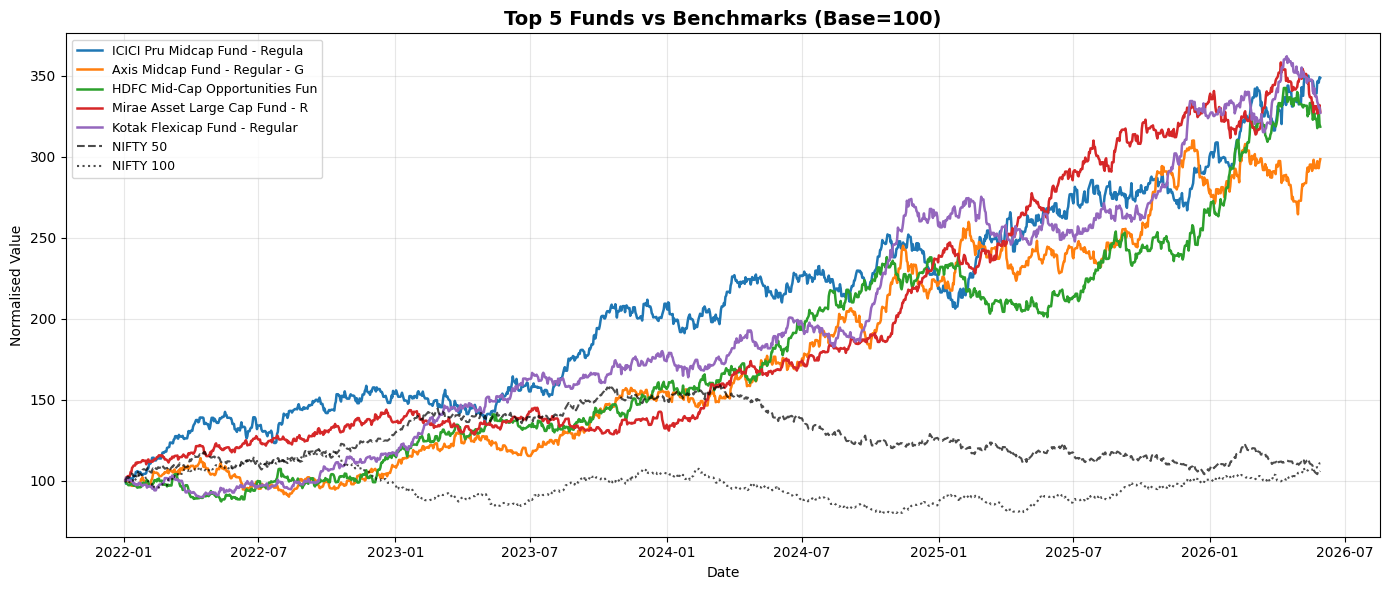


Tracking Error vs NIFTY 100:
  ICICI Pru Midcap Fund - Regular - G      TE=23.20%
  Axis Midcap Fund - Regular - Growth      TE=23.77%
  HDFC Mid-Cap Opportunities Fund - R      TE=22.87%
  Mirae Asset Large Cap Fund - Regula      TE=18.97%
  Kotak Flexicap Fund - Regular - Gro      TE=20.64%


In [9]:

top5_codes = score_df.head(5)['amfi_code'].tolist()
nifty50  = bench[bench['index_name']=='NIFTY50'].set_index('date')['close_value']
nifty100 = bench[bench['index_name']=='NIFTY100'].set_index('date')['close_value']

fig, ax = plt.subplots(figsize=(14,6))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

for code, col in zip(top5_codes, colors):
    s = nav_by_fund[code].dropna()
    s = s / s.iloc[0] * 100
    name = score_df[score_df['amfi_code']==code]['scheme_name'].values[0][:30]
    ax.plot(s.index, s.values, label=name, lw=1.8, color=col)

n50n = nifty50 / nifty50.iloc[0] * 100
n100n = nifty100 / nifty100.iloc[0] * 100
ax.plot(n50n.index, n50n.values, 'k--', lw=1.5, label='NIFTY 50', alpha=0.7)
ax.plot(n100n.index, n100n.values, 'k:', lw=1.5, label='NIFTY 100', alpha=0.7)

ax.set_title('Top 5 Funds vs Benchmarks (Base=100)', fontweight='bold', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Normalised Value')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS/'chart_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Tracking error
print('\nTracking Error vs NIFTY 100:')
te_rows = []
for code in top5_codes:
    fund_r = daily_ret[code].dropna()
    common = fund_r.index.intersection(nifty100.pct_change().dropna().index)
    if len(common) > 50:
        te = (fund_r.loc[common] - nifty100.pct_change().loc[common]).std() * np.sqrt(252) * 100
        name = score_df[score_df['amfi_code']==code]['scheme_name'].values[0][:35]
        te_rows.append({'Fund': name, 'Tracking_Error_pct': round(te,2)})
        print(f'  {name:<40} TE={te:.2f}%')


## Additional Performance Charts

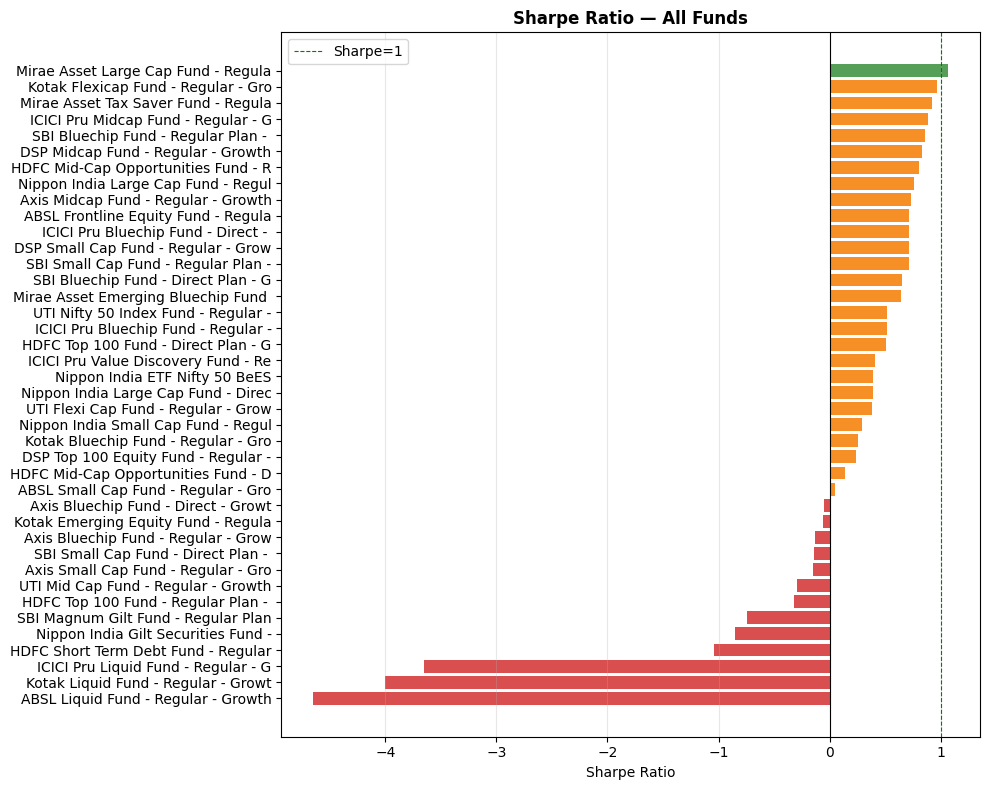

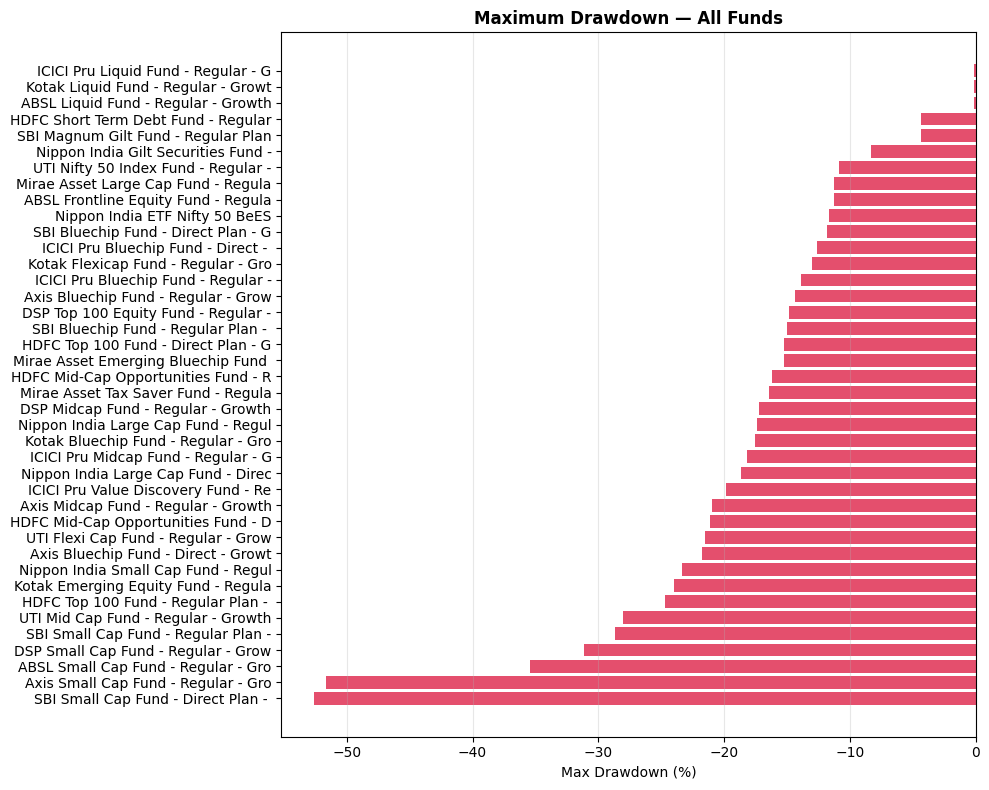

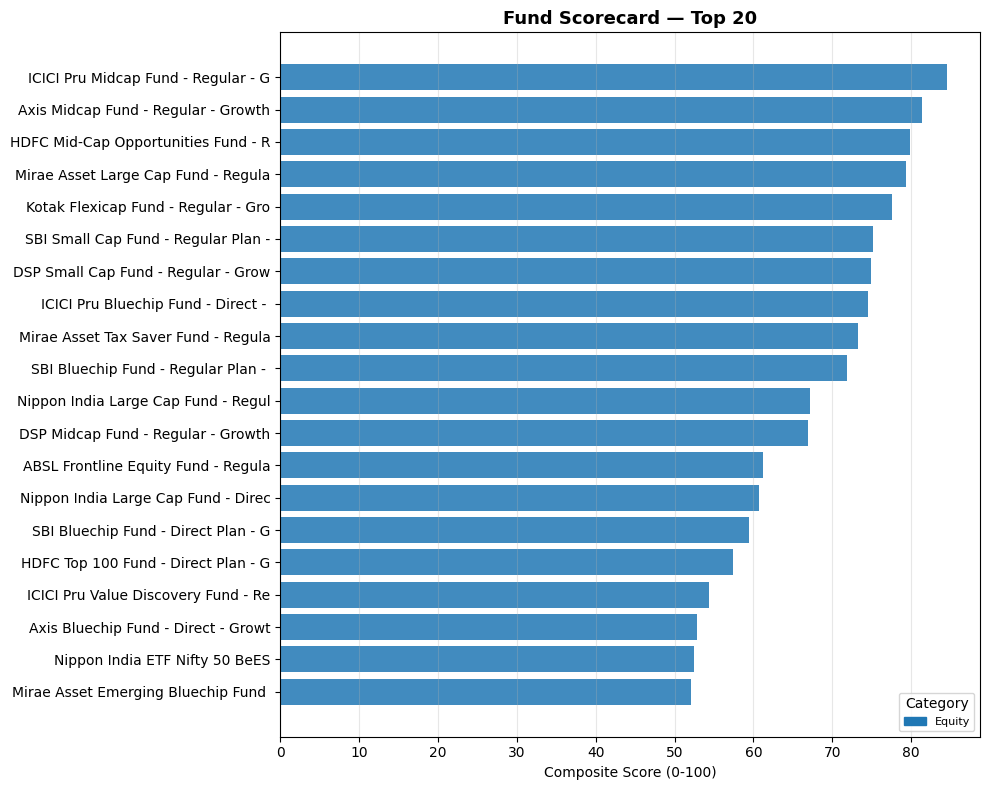

All performance charts saved


In [10]:

# Sharpe ranking chart
sharpe_sorted = sharpe_df.sort_values('sharpe', ascending=True)
fig, ax = plt.subplots(figsize=(10,8))
colors = ['#d32f2f' if v < 0 else '#388e3c' if v > 1 else '#f57c00'
          for v in sharpe_sorted['sharpe']]
ax.barh(sharpe_sorted['scheme_name'].str[:35], sharpe_sorted['sharpe'],
        color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(1, color='green', ls='--', lw=0.8, label='Sharpe=1')
ax.set_xlabel('Sharpe Ratio'); ax.set_title('Sharpe Ratio — All Funds', fontweight='bold')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS/'chart_sharpe_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# Max drawdown chart
dd_sorted = dd_df.sort_values('max_drawdown_pct')
fig, ax = plt.subplots(figsize=(10,8))
ax.barh(dd_sorted['scheme_name'].str[:35], dd_sorted['max_drawdown_pct'],
        color='crimson', alpha=0.75)
ax.set_xlabel('Max Drawdown (%)'); ax.set_title('Maximum Drawdown — All Funds', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS/'chart_max_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

# Fund Scorecard bar
top20 = score_df.head(20).sort_values('composite_score')
fig, ax = plt.subplots(figsize=(10,8))
categories = top20['category'].unique()
colors_map = dict(zip(categories, sns.color_palette('tab10', len(categories))))
bar_colors = top20['category'].map(colors_map)
ax.barh(top20['scheme_name'].str[:35], top20['composite_score'], color=bar_colors, alpha=0.85)
handles = [plt.Rectangle((0,0),1,1, color=colors_map[c]) for c in categories]
ax.legend(handles, categories, title='Category', fontsize=8)
ax.set_xlabel('Composite Score (0-100)')
ax.set_title('Fund Scorecard — Top 20', fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS/'chart_fund_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
print('All performance charts saved')
